# Performance benchmarking



In [1]:
import sys
if "code" not in sys.path: sys.path.insert(0, "code")   # model modules live in code/
from tile_model import Hardware, data_bytes, divup
from fa import flash_attention
from mlp import mlp
from helper import T, S, H, G, K, D, F, L, plot_roofline
from parallel import tensor_parallel_prefill, tensor_parallel_decode

Per layer, one 2048-token sequence (ridge 17.2 op/byte)
  FA          34.4 Gop      40.0 MiB    819.6 op/byte    882 op/cycle     39.0 ms
  MLP        721.6 Gop    1896.0 MiB    362.9 op/byte   1092 op/cycle    660.9 ms
  FA+MLP     755.9 Gop    1936.0 MiB    372.4 op/byte   1080 op/cycle    699.9 ms
TTFT:  22.4 s


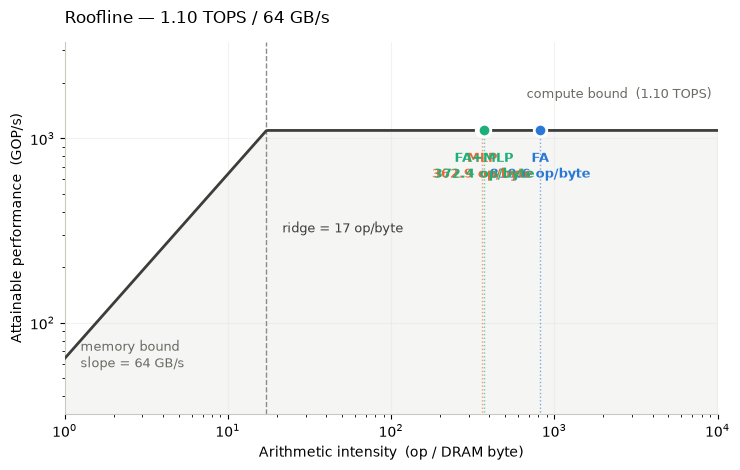

In [2]:
hw = Hardware()
Mt = 192
fa = flash_attention(T=T, S=S, H=H, G=G, Br=192, Bc=256, Br_sa1=None, R=256, hw=hw, verbose=False)
ml = mlp(M=T, D=D, F=F, Mt=Mt, Ft=256, Mt_sa1=None, R=256, hw=hw, verbose=False)

# FA, K for K groups per layer
fa_ops   = K * 2 * 2 * G * H * T * (T + 1) // 2           # QK^T + PV
fa_bytes = K * (data_bytes((2*S, H), 16) + data_bytes((2*G*T, H), 16))
fa_cyc   = K * fa['cycles']

# MLP:
mlp_ops   = 2 * T * 3 * D * F                              # gate, up, down
mlp_bytes = data_bytes((3*T, D), 16) + divup(T, Mt) * data_bytes((3*D, F), 8)
mlp_cyc   = ml['cycles']

ridge_ops, ridge_mem = 2 * 552, hw.dma_bw                    # op/cycle, byte/cycle
rows = [("FA", fa_ops, fa_bytes, fa_cyc), ("MLP", mlp_ops, mlp_bytes, mlp_cyc),
        ("FA+MLP", fa_ops + mlp_ops, fa_bytes + mlp_bytes, fa_cyc + mlp_cyc)]

print(f"Per layer, one {T}-token sequence (ridge {ridge_ops/ridge_mem:.1f} op/byte)")
for name, ops, nbytes, cyc in rows:
    print(f"  {name:7s} {ops/1e9:8.1f} Gop  {nbytes/2**20:8.1f} MiB  "
          f"{ops/nbytes:7.1f} op/byte  {ops/cyc:5.0f} op/cycle  {hw.time_us(cyc)/1e3:7.1f} ms")

plot_roofline([(name, round(ops/nbytes, 1)) for name, ops, nbytes, _ in rows], ridge_ops, ridge_mem)

print("TTFT: ", round(L * hw.time_us(cyc)/1e3/1e3, 1), "s")

In [3]:
print(fa["utilization"])
print(ml["utilization"])

{'DMA': 0.023745623875637938, 'VCPU': 0.5843241536209717, 'SA1+SA2': 0.9943613377248647}
{'DMA': 0.047767138692194504, 'VCPU': 0.1672367932151232, 'SA1+SA2': 0.9997724950974342}


Per layer, one decode step of B=16 sequences at S=2048 context (ridge 17.2 op/byte)
  FA        0.537 Gop    64.2 MiB    8.0 op/byte    118 op/cycle   4.564 ms     23% of the memory roof
  MLP       5.637 Gop   168.4 MiB   31.9 op/byte   1029 op/cycle   5.479 ms     93% of the compute roof
  FA+MLP    6.174 Gop   232.6 MiB   25.3 op/byte    615 op/cycle  10.043 ms     56% of the compute roof
TPOT: 321.4 ms/step = 20.09 ms/token, 50 tok/s aggregate
  floors per step: weights 88.1 ms, KV cache 33.6 ms


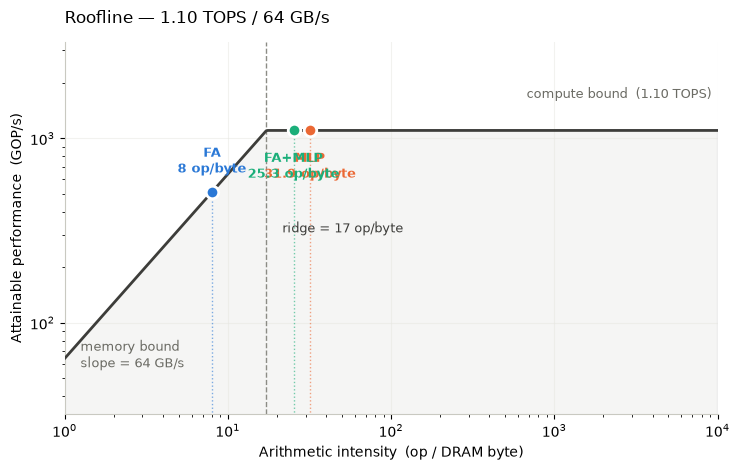

In [4]:
from fa import flash_decode
from mlp import mlp_decode
from helper import B

# One decode step: every sequence emits one token. Attention runs per sequence
# (each owns its KV cache) -> B*K groups per layer; the MLP runs ONCE for the
# whole batch, because all B token rows share the same weights.
fad = flash_decode(S=S, H=H, G=G, Bc=1024, R=256, hw=hw, verbose=False)
mld = mlp_decode(M=B, D=D, F=F, Ft=256, R=256, hw=hw, verbose=False)

fad_ops   = B * K * 2 * 2 * G * H * S                    # QK^T + PV over every cached key
fad_bytes = B * K * (data_bytes((2*S, H), 8)             # INT8 K + pre-transposed V
                     + data_bytes((2*G, H), 16))         # Q16 in, O16 out
fad_cyc   = B * K * fad['cycles']

mld_ops   = 2 * B * 3 * D * F                            # gate, up, down
mld_bytes = data_bytes((3*B, D), 16) + data_bytes((3*D, F), 8)   # weights once per step
mld_cyc   = mld['cycles']

rows = [("FA", fad_ops, fad_bytes, fad_cyc), ("MLP", mld_ops, mld_bytes, mld_cyc),
        ("FA+MLP", fad_ops + mld_ops, fad_bytes + mld_bytes, fad_cyc + mld_cyc)]

print(f"Per layer, one decode step of B={B} sequences at S={S} context "
      f"(ridge {ridge_ops/ridge_mem:.1f} op/byte)")
for name, ops, nbytes, cyc in rows:
    roof = min(ridge_ops, ops/nbytes * ridge_mem)        # the roofline at this intensity
    print(f"  {name:7s} {ops/1e9:7.3f} Gop {nbytes/2**20:7.1f} MiB {ops/nbytes:6.1f} op/byte"
          f" {ops/cyc:6.0f} op/cycle {hw.time_us(cyc)/1e3:7.3f} ms"
          f"   {100*ops/cyc/roof:4.0f}% of the {'compute' if roof == ridge_ops else 'memory'} roof")

plot_roofline([(name, round(ops/nbytes, 1)) for name, ops, nbytes, _ in rows],
              ridge_ops, ridge_mem)

step = L * (fad_cyc + mld_cyc)
print(f"TPOT: {hw.time_us(step)/1e3:.1f} ms/step = {hw.time_us(step)/1e3/B:.2f} ms/token, "
      f"{B/(hw.time_us(step)/1e6):.0f} tok/s aggregate")
print(f"  floors per step: weights {L*3*D*F/hw.dma_bw/1e6:.1f} ms, "
      f"KV cache {L*B*K*2*S*H/hw.dma_bw/1e6:.1f} ms")

In [5]:
print(fad["utilization"])
print(mld["utilization"])

{'DMA': 0.29656429673257606, 'VCPU': 0.3814892721918384, 'SA1+SA2': 0.5373720375823867}
{'DMA': 0.5118769395423999, 'VCPU': 0.20709982710547406, 'SA1+SA2': 0.9912468610052485}


# Parallelization

In [6]:
from tile_model import Host

system = Host(n=4, hw=hw)                      # 1 host CPU + DRAM, 4 accelerators, 6 links
print(system.accelerators)

# DRAM -> acc0 SRAM (host DMA), then acc0 -> acc1 over their link (bw = inf by default)
load = system.dram(0, (S, H), 8, name='K8')

link = system.transfer(0, 1, (S, H), 8, name='K8', release=True)

print('load cycles:', load, '| link cycles:', link)
print('acc0:', system[0].sram.buffers, '| acc1:', system[1].sram.buffers)

[Accelerator('acc0', peers=['acc1', 'acc2', 'acc3']), Accelerator('acc1', peers=['acc0', 'acc2', 'acc3']), Accelerator('acc2', peers=['acc0', 'acc1', 'acc3']), Accelerator('acc3', peers=['acc0', 'acc1', 'acc2'])]
load cycles: 4496 | link cycles: 0
acc0: {} | acc1: {'K8': {'shape': (2048, 128), 'dtype': 'int8', 'bytes': 262144}}


## Tensor parallelization

In [7]:
## Prefill

h = Hardware()
base_prefill = tensor_parallel_prefill(1, Mt, h)['cycles']   # one accelerator, same hardware
base_decode = tensor_parallel_decode(1, h)['cycles']   # one accelerator, same hardware
n = 4

print("*" * 12, "Prefill", "*" * 12)
print(f"Per layer, one {T}-token sequence")
tpr = tensor_parallel_prefill(n, Mt, h)
ms = lambda c: h.time_us(c) / 1e3
print(f"n={n} \n"
      f"attention {ms(tpr['att']):6.1f} ms \n"
      f"MLP {ms(tpr['mlp']):6.1f} ms  \n"
      f"all-reduce {ms(tpr['allreduce']):6.1f} ms \n"
      f"layer {ms(tpr['cycles']):6.1f}ms "
      f"speedup: x{base_prefill / tpr['cycles']:4.2f} \n"
      f"TTFT {L * ms(tpr['cycles']) / 1e3:4.1f} s \n"
      f"bottleneck: attention <- {tpr['bound'][0]}\n"
      f"MLP <- {tpr['bound'][1]}")


print("*" * 12, "Decode", "*" * 12)
print(f"Per layer, one decode step of B={B} sequences at S={S} context")
tpd = tensor_parallel_decode(n, h)
ms = lambda c: h.time_us(c) / 1e3
print(f"n={n} \n"
      f"attention {ms(tpd['att']):6.2f} ms \n"
      f"MLP {ms(tpd['mlp']):6.2f} ms  \n"
      f"all-reduce {ms(tpd['allreduce']):6.3f} ms \n"
      f"layer {ms(tpd['cycles']):6.2f}ms "
      f"speedup: x{base_decode / tpd['cycles']:4.2f} \n"
      f"TPOT {L * ms(tpd['cycles']) / B:5.2f} ms/token, {B / (L * ms(tpd['cycles']) / 1e3):.0f} tok/s \n"
      f"bottleneck: attention <- {tpd['bound'][0]}\n"
      f"MLP <- {tpd['bound'][1]}")


************ Prefill ************
Per layer, one 2048-token sequence
n=4 
attention   27.8 ms 
MLP  369.9 ms  
all-reduce    0.2 ms 
layer  397.8ms speedup: x1.76 
TTFT 12.7 s 
bottleneck: attention <- host command interface
MLP <- host command interface
************ Decode ************
Per layer, one decode step of B=16 sequences at S=2048 context
n=4 
attention   1.72 ms 
MLP   2.93 ms  
all-reduce  0.014 ms 
layer   4.66ms speedup: x2.16 
TPOT  9.32 ms/token, 107 tok/s 
bottleneck: attention <- host command interface
MLP <- host command interface


In [11]:
## Pipeline x tensor parallel prefill

from parallel import pipeline_tensor_parallel_prefill
from helper import B, T, L

nt, np_ = 2, 2     # nt accelerators per tensor-parallel group, np_ groups as pipeline stages

print("*" * 12, "Pipeline x tensor parallel prefill", "*" * 12)
print(f"All {L} layers, B={B} sequences of {T} tokens, "
      f"nt={nt} x np={np_} = {nt * np_} accelerators")
ms = lambda c: h.time_us(c) / 1e3

for one_host in (True, False):
    ptp = pipeline_tensor_parallel_prefill(nt, np_, Mt, m=B, hw=h, one_host=one_host)
    layer = ptp['layer']
    print(f"--- {'one shared host' if one_host else 'one host per stage'} \n"
          f"layers per stage {ptp['stages']} \n"
          f"layer {ms(layer['cycles']):6.1f} ms "
          f"(attention {ms(layer['att']):.1f}, MLP {ms(layer['mlp']):.1f}, all-reduce {ms(layer['allreduce']):.1f}) \n"
          f"stage hand-off {ms(ptp['send']):6.2f} ms \n"
          f"TTFT {ms(ptp['ttft']) / 1e3:5.1f} s \n"
          f"batch {ms(ptp['cycles']) / 1e3:6.1f} s, {B * T / (ms(ptp['cycles']) / 1e3):.0f} tok/s \n"
          f"bubble {ptp['bubble']:.1%} \n"
          f"speedup: x{ptp['speedup']:4.2f} \n"
          f"bottleneck: attention <- {ptp['bound'][0]}\n"
          f"MLP <- {ptp['bound'][1]}")

# print("\n" + "*" * 12, "Sweep", "*" * 12)
# print(f"{'nt':>2} {'np':>2} {'host':>9} {'acc':>3} {'TTFT s':>7} {'batch s':>8} "
#       f"{'bubble':>6} {'speedup':>7}  bottleneck (MLP)")
# for one_host in (True, False):
#     for nt_, np__ in [(1, 1), (2, 1), (4, 1), (1, 2), (1, 4), (2, 2), (2, 4), (4, 4)]:
#         r = pipeline_tensor_parallel_prefill(nt_, np__, Mt, m=B, hw=h, one_host=one_host)
#         print(f"{nt_:>2} {np__:>2} {'shared' if one_host else 'per-stage':>9} {nt_ * np__:>3} "
#               f"{ms(r['ttft']) / 1e3:7.2f} {ms(r['cycles']) / 1e3:8.1f} "
#               f"{r['bubble']:6.1%} x{r['speedup']:6.2f}  {r['bound'][1]}")


************ Pipeline x tensor parallel prefill ************
All 32 layers, B=16 sequences of 2048 tokens, nt=2 x np=2 = 4 accelerators
--- one shared host 
layers per stage [16, 16] 
layer  795.4 ms (attention 55.6, MLP 739.7, all-reduce 0.0) 
stage hand-off   0.01 ms 
TTFT  25.5 s 
batch  216.3 s, 151 tok/s 
bubble 5.9% 
speedup: x1.66 
bottleneck: attention <- host command interface
MLP <- host command interface
--- one host per stage 
layers per stage [16, 16] 
layer  397.7 ms (attention 27.8, MLP 369.9, all-reduce 0.0) 
stage hand-off   0.01 ms 
TTFT  12.7 s 
batch  108.2 s, 303 tok/s 
bubble 5.9% 
speedup: x3.31 
bottleneck: attention <- host command interface
MLP <- host command interface
